In [56]:
import tensorflow as tf
print(tf.__version__)


2.20.0


In [57]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


In [58]:
# Load the Fashion MNIST dataset
fashion_mnist = tf.keras.datasets.fashion_mnist

(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

print("Training Images:", train_images.shape)
print("Training Labels:", train_labels.shape)
print("Testing Images:", test_images.shape)
print("Testing Labels:", test_labels.shape)

Training Images: (60000, 28, 28)
Training Labels: (60000,)
Testing Images: (10000, 28, 28)
Testing Labels: (10000,)


In [59]:
class_names = [
    'T-shirt',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle Boot'
]

print(class_names)

['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle Boot']


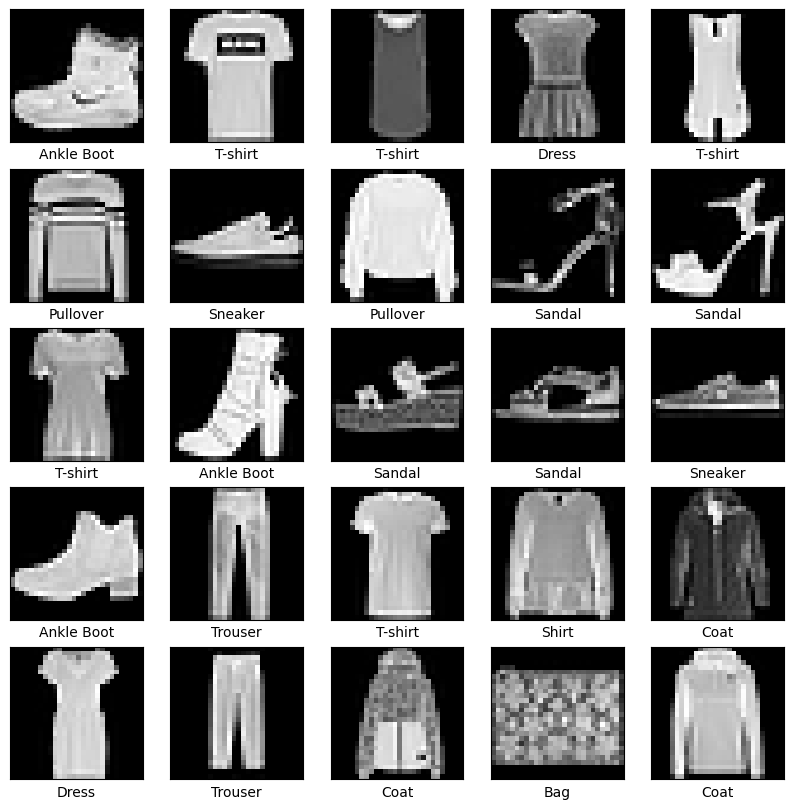

Images normalized successfully!


In [60]:
plt.figure(figsize=(10,10))

for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i], cmap='gray')
    plt.xlabel(class_names[train_labels[i]])

plt.show()
train_images = train_images / 255.0
test_images = test_images / 255.0

print("Images normalized successfully!")

In [54]:
# Build CNN Model

model = tf.keras.Sequential([

    # First Convolution Layer
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),

    # First Pooling Layer
    tf.keras.layers.MaxPooling2D((2,2)),

    # Second Convolution Layer
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),

    # Second Pooling Layer
    tf.keras.layers.MaxPooling2D((2,2)),

    # Convert 2D data into 1D
    tf.keras.layers.Flatten(),

    # Hidden Layer
    tf.keras.layers.Dense(128, activation='relu'),

    # Output Layer (10 Classes)
    tf.keras.layers.Dense(10, activation='softmax')
])

print("CNN Model Created Successfully!")
train_images = train_images.reshape((-1,28,28,1))
test_images = test_images.reshape((-1,28,28,1))

print(train_images.shape)
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model Compiled Successfully!")
history = model.fit(
    train_images,
    train_labels,
    epochs=5,
    validation_data=(test_images, test_labels)
)
# Evaluate the model

test_loss, test_accuracy = model.evaluate(test_images, test_labels)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

CNN Model Created Successfully!
(60000, 28, 28, 1)
Model Compiled Successfully!
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 65s 34ms/step - accuracy: 0.8318 - loss: 0.4595 - val_accuracy: 0.8749 - val_loss: 0.3530
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 62s 33ms/step - accuracy: 0.8899 - loss: 0.3020 - val_accuracy: 0.8911 - val_loss: 0.3023
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 62s 33ms/step - accuracy: 0.9068 - loss: 0.2545 - val_accuracy: 0.8952 - val_loss: 0.2806
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 60s 32ms/step - accuracy: 0.9168 - loss: 0.2225 - val_accuracy: 0.9049 - val_loss: 0.2570
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 61s 33ms/step - accuracy: 0.9262 - loss: 0.1964 - val_accuracy: 0.9110 - val_loss: 0.2440
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9110 - loss: 0.2440
Test Accuracy: 0.9110000133514404
Test Loss: 0.2440013736486435


In [65]:
predictions = model.predict(test_images)
import numpy as np
import matplotlib.pyplot as plt

index = 15

plt.imshow(test_images[index].reshape(28,28), cmap='gray')
plt.title("Predicted: " + class_names[np.argmax(predictions[index])])
plt.axis('off')
plt.show()

print("Actual:", class_names[test_labels[index]])
print("Predicted:", class_names[np.argmax(predictions[index])])

ValueError: Exception encountered when calling Sequential.call().

[1mCannot take the length of shape with unknown rank.[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=<unknown>, dtype=float32)
  • training=False
  • mask=None
  • kwargs=<class 'inspect._empty'>

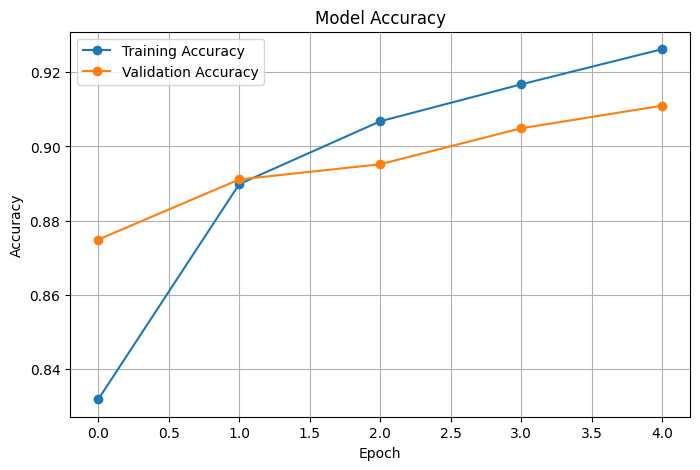

In [61]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], marker='o', label='Training Accuracy')
plt.plot(history.history['val_accuracy'], marker='o', label='Validation Accuracy')

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

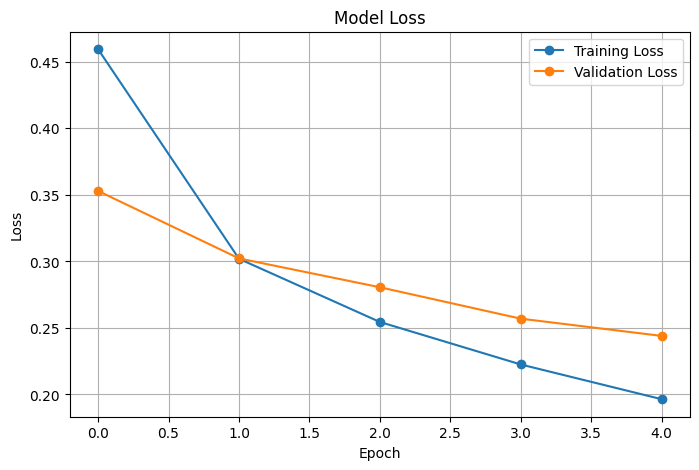

In [62]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], marker='o', label='Training Loss')
plt.plot(history.history['val_loss'], marker='o', label='Validation Loss')

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

In [63]:
model.save("FashionMNIST_CNN_Model.keras")

print("Model Saved Successfully!")

Model Saved Successfully!
